# Mutational signature analysis — ΔMIC of single-position mutants

*(adapted from `karol_bootstrap.ipynb`)*

This notebook builds **amino-acid → amino-acid mutational signatures** for the two Veltri
benchmark splits, scored by the change in predicted antimicrobial activity (MIC):

- **`veltri_positive`** — peptides labelled as antimicrobial (active).
- **`veltri_negative`** — peptides labelled as non-antimicrobial (inactive).

For every parent peptide we take all of its single-position mutants and, for each of the
34 bacterial strains, compute the **log2 fold-change in MIC**

$$\Delta\text{logMIC} = \log_2(\text{MIC}_{\text{mutant}}) - \log_2(\text{MIC}_{\text{parent}}).$$

A **negative** ΔlogMIC means the mutation **lowered the MIC → made the peptide more active
(better)**; a **positive** ΔlogMIC means the mutation **raised the MIC → made it less
active (worse)**. We aggregate these changes per *(parent residue → mutant residue)* pair
into a 20×20 matrix, separately for **Gram-negative** and **Gram-positive** strains.

All MIC values come from the APEX predictions in `results/data/all_in/` (cached per split
under `results/data/all_in/_cache/`).

**Colour convention** (matching the `count_mic_changes` notebook style — clean seaborn
heatmap with amino-acid group bars — but on a diverging scale): **green = the mutation
lowers MIC (good)**, **red = the mutation raises MIC (bad)**, white = no net change.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Literal, Optional
from matplotlib.colors import Colormap, LinearSegmentedColormap

# --- Colour map: green (MIC down / more active) -> white (no change) -> red (MIC up / less active).
# Soft, low-contrast tones to match the look of the count_mic_changes notebook.
GREEN_WHITE_RED = LinearSegmentedColormap.from_list(
    "green_white_red",
    ["#1a9641", "#a6d96a", "#ffffff", "#fdae61", "#d7191c"],
)

ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")

# --- Amino-acid groupings used to order/annotate the heatmap axes (from count_mic_changes).
AMINO_ACID_CLASSES = {
    "polarity": {
        "hydrophobic": ["A", "V", "L", "I", "M", "F", "W", "P", "G"],
        "polar": ["S", "T", "Y", "C", "N", "Q"],
        "charged": ["K", "R", "H", "D", "E"],
    },
    "charge": {
        "positive": ["K", "R", "H"],
        "negative": ["D", "E"],
        "neutral": ["A", "V", "L", "I", "M", "F", "W", "P", "G", "S", "T", "Y", "C", "N", "Q"],
    },
    "chemical_type": {
        "aliphatic": ["G", "A", "V", "L", "I"],
        "aromatic": ["F", "Y", "W"],
        "hydroxyl": ["S", "T", "Y"],
        "acidic": ["D", "E"],
        "amide": ["N", "Q"],
        "basic": ["K", "R", "H"],
        "sulfur": ["C", "M"],
        "imino": ["P"],
    },
}

# --- Gram classification of the 34 APEX strains (column order is identical across all
# all_in caches). Indices refer to the bacterial value columns (after the id columns).
gram_neg = [0, 1, 2, 3, 4, 5, 6, 11, 12, 13, 16, 17, 18, 19, 20, 22, 23, 24, 29, 30, 31, 32]
gram_pos = [7, 8, 9, 10, 14, 15, 21, 25, 26, 27, 28, 33]
assert sorted(gram_neg + gram_pos) == list(range(34))

project_root = Path(".").resolve()
while project_root.name != "pep-compass" and project_root.parent != project_root:
    project_root = project_root.parent
assert project_root.name == "pep-compass", project_root
CACHE = project_root / "results" / "data" / "all_in" / "_cache"
print("Project root:", project_root)
print("Cache dir   :", CACHE)

Project root: C:\Users\Karol\Desktop\PepCompass\pep-compass
Cache dir   : C:\Users\Karol\Desktop\PepCompass\pep-compass\results\data\all_in\_cache


## 1. Load the cached parent + mutant MIC tables

For each split we load two tables extracted from `results/data/all_in/`:

- **parents** — one row per parent peptide, with predicted MIC for all 34 strains.
- **mutants** — one row per single-position mutant (`mutant`, `position`, `parent`), with
  predicted MIC for the same 34 strains.

The `veltri_negative` cache ships with the repo; the `veltri_positive` cache is built by
streaming the full `peptides_mutants_apex.csv` and keeping rows whose parent belongs to the
`veltri_positive` split (see `_build_veltri_positive_cache.py`).

In [2]:
def load_split(tag: str):
    parents = pd.read_parquet(CACHE / f"parents_hydramp_{tag}.parquet")
    mutants = pd.read_parquet(CACHE / f"mutants_hydramp_{tag}.parquet")
    return parents, mutants

parents_neg, mutants_neg = load_split("veltri_negative")
parents_pos, mutants_pos = load_split("veltri_positive")

# Bacterial value columns are everything after the id columns in the parents table.
bac_cols = parents_neg.columns.tolist()[4:]
assert len(bac_cols) == 34, len(bac_cols)

for name, p, m in [("veltri_negative", parents_neg, mutants_neg),
                   ("veltri_positive", parents_pos, mutants_pos)]:
    print(f"{name:16s}  parents={len(p):>5}  mutants={len(m):>7}")
parents_pos.head(3)

veltri_negative   parents=  854  mutants=  77297
veltri_positive   parents=  892  mutants=  58318


,sequence,within_dataset_id,source_file,dataset,A. baumannii ATCC 19606,E. coli ATCC 11775,E. coli AIG221,E. coli AIG222,K. pneumoniae ATCC 13883,P. aeruginosa PA01,...,B. ovatus ATCC8483,E. rectale ATCC33656,C. symbiosum,R. obeum,R. torques,E. coli Nissle,Salmonella enterica ATCC 9150 (BEIRES NR-515),Salmonella enterica (BEIRES NR-170),Salmonella enterica ATCC 9150 (BEIRES NR-174),L. monocytogenes ATCC 19111 (BEIRES NR-106)
0,AAFRGCWTKNYSPKPCL,AP01914,veltri_positive.csv,hydramp_veltri_positive,132.40402,133.626300,129.96991,130.09193,125.685550,130.52882,...,351.28937,282.24520,135.27213,136.04002,112.359130,2073.4421,103.208290,1161.52000,585.94464,114.435974
1,AAKIILNPKFRCKAAFC,19;AP02716,mic_data.csv;veltri_positive.csv,hydramp_mic_data;hydramp_veltri_positive,76.72857,88.013794,94.08178,107.35209,72.392044,71.10947,...,271.52360,251.83151,108.84853,111.14645,68.708360,1937.6511,42.513912,966.23065,399.27603,69.120090
2,AALKGCWTKSIPPKPCSGKR,AP00490,veltri_positive.csv,hydramp_veltri_positive,121.46822,125.525246,122.91966,130.86966,115.101060,118.97319,...,317.19880,259.80078,135.53363,134.06630,109.166954,1473.4680,90.662964,1083.88090,531.22460,104.696730


## 2. Compute ΔlogMIC for every mutant

`compute_diff` merges each mutant onto its parent (`mutant.parent == parent.sequence`) and,
for every strain column, computes `log2(MIC_mutant) - log2(MIC_parent)`. The result is the
log2 fold-change in MIC produced by that single substitution, per strain.

In [3]:
def compute_diff(
    parents_df: pd.DataFrame,
    mutants_df: pd.DataFrame,
    match_col_parents: str,
    match_col_mutants: str,
    value_cols: list[str],
    value_preprocessing: Optional[Literal["log"]],
    add_relative: bool,
) -> pd.DataFrame:
    """Difference between each mutant and its parent for every value column."""
    merged = mutants_df.merge(
        parents_df, left_on=match_col_mutants, right_on=match_col_parents,
        suffixes=("_mutants", "_parents"),
    )
    if value_preprocessing is None:
        vprep_fn, suffix = (lambda x: x), ""
    elif value_preprocessing == "log":
        vprep_fn, suffix = np.log2, "_log"
    else:
        raise ValueError(f"Invalid value_preprocessing: {value_preprocessing}")

    for value_col in value_cols:
        merged[f"{value_col}{suffix}_diff"] = (
            vprep_fn(merged[f"{value_col}_mutants"]) - vprep_fn(merged[f"{value_col}_parents"])
        )
        if add_relative:
            merged[f"{value_col}{suffix}_diff_relative"] = (
                merged[f"{value_col}{suffix}_diff"] / vprep_fn(merged[f"{value_col}_parents"])
            )
    return merged


def prepare_diff(parents_df, mutants_df):
    """Merge, compute ΔlogMIC, drop padding/identity rows, and label the changed residue."""
    diff = compute_diff(
        parents_df, mutants_df,
        match_col_parents="sequence", match_col_mutants="parent",
        value_cols=bac_cols, value_preprocessing="log", add_relative=False,
    )
    diff = diff.dropna(subset=["parent", "mutant", "position"]).drop_duplicates(
        subset=["parent", "mutant", "position"]
    )
    pos = diff["position"].astype(int)
    diff = diff[(pos < diff["parent"].str.len()) & (pos < diff["mutant"].str.len())]
    pos = diff["position"].astype(int)
    diff["parent_aa"] = [s[i] for s, i in zip(diff["parent"], pos)]
    diff["mutant_aa"] = [s[i] for s, i in zip(diff["mutant"], pos)]
    diff = diff[diff["parent_aa"] != diff["mutant_aa"]]
    return diff

diff_neg = prepare_diff(parents_neg, mutants_neg)
diff_pos = prepare_diff(parents_pos, mutants_pos)
print(f"veltri_negative usable single-AA mutations: {len(diff_neg):,}")
print(f"veltri_positive usable single-AA mutations: {len(diff_pos):,}")

veltri_negative usable single-AA mutations: 22,652
veltri_positive usable single-AA mutations: 17,943


## 3. Aggregate into 20×20 mutational-signature matrices

For each *(parent residue → mutant residue)* pair we average ΔlogMIC over **all mutations of
that type and all strains in a Gram group**, giving one mean value per cell. We build this
separately for Gram-negative and Gram-positive strains, plus a raw count matrix.

In [4]:
delta_cols = [f"{c}_log_diff" for c in bac_cols]
neg_delta_cols = [delta_cols[i] for i in gram_neg]
pos_delta_cols = [delta_cols[i] for i in gram_pos]


def build_signature_matrices(diff: pd.DataFrame):
    """Return (gram_neg_matrix, gram_pos_matrix, count_matrix) of mean ΔlogMIC per AA->AA."""
    neg_m = pd.DataFrame(np.nan, index=ALL_AA, columns=ALL_AA, dtype=float)
    pos_m = pd.DataFrame(np.nan, index=ALL_AA, columns=ALL_AA, dtype=float)
    cnt = pd.DataFrame(0, index=ALL_AA, columns=ALL_AA, dtype=int)
    for (p_aa, m_aa), g in diff.groupby(["parent_aa", "mutant_aa"]):
        if p_aa not in ALL_AA or m_aa not in ALL_AA:
            continue
        neg_m.at[p_aa, m_aa] = np.nanmean(g[neg_delta_cols].to_numpy())
        pos_m.at[p_aa, m_aa] = np.nanmean(g[pos_delta_cols].to_numpy())
        cnt.at[p_aa, m_aa] = len(g)
    return neg_m, pos_m, cnt

neg_gramneg, neg_grampos, neg_cnt = build_signature_matrices(diff_neg)
pos_gramneg, pos_grampos, pos_cnt = build_signature_matrices(diff_pos)

# A symmetric colour limit shared by all heatmaps, so the splits are directly comparable.
_all_vals = np.concatenate([
    m.to_numpy().ravel() for m in [neg_gramneg, neg_grampos, pos_gramneg, pos_grampos]
])
VLIM = float(np.nanpercentile(np.abs(_all_vals), 98))
print(f"Shared symmetric colour limit (98th pct of |ΔlogMIC|): ±{VLIM:.3f}")

Shared symmetric colour limit (98th pct of |ΔlogMIC|): ±0.275


## 4. Plotting helper

The heatmap styling is taken from the `count_mic_changes` notebook: a square seaborn
heatmap with the axes **sorted by amino-acid group**, group separator lines, coloured group
bars and labels on both axes, and the self→self diagonal masked. The only change is the
colour map — here a diverging **green→white→red** scale encoding the *direction* of the MIC
change.

In [5]:
def _as_aa_frame(matrix) -> pd.DataFrame:
    if isinstance(matrix, pd.DataFrame):
        return matrix.copy()
    matrix = np.asarray(matrix)
    n = matrix.shape[0]
    labels = ALL_AA if n == len(ALL_AA) else [f"AA{i + 1}" for i in range(n)]
    return pd.DataFrame(matrix, index=labels, columns=labels)


def plot_signature_matrix(
    matrix,
    classification: str | None = "chemical_type",
    cmap=GREEN_WHITE_RED,
    title: str | None = None,
    mask_diagonal: bool = True,
    annot: bool = False,
    vmin: float | None = None,
    vmax: float | None = None,
    figsize: tuple = (9, 8),
    group_colors: dict | None = None,
    cbar_label: str | None = "mean ΔlogMIC   (green ↓ better · red ↑ worse)",
    return_fig: bool = False,
    ax=None,
):
    """Green→white→red AA×AA heatmap of mean ΔlogMIC, grouped by an AA classification."""
    df = _as_aa_frame(matrix)
    aas = list(df.index)

    group_sizes: list[int] = []
    group_names: list[str] = []
    if classification is not None:
        if classification not in AMINO_ACID_CLASSES:
            raise ValueError(f"Unknown classification: {classification}")
        groups = AMINO_ACID_CLASSES[classification]
        sorted_aa, assigned = [], set()
        for gname, members in groups.items():
            present = [aa for aa in aas if aa in members and aa not in assigned]
            if present:
                sorted_aa.extend(present); assigned.update(present)
                group_sizes.append(len(present)); group_names.append(gname)
        sorted_aa.extend([aa for aa in aas if aa not in assigned])
        df = df.loc[sorted_aa, sorted_aa]

    mask = df.isna()
    if mask_diagonal:
        diag = np.zeros(df.shape, dtype=bool)
        np.fill_diagonal(diag, True)
        mask = mask | diag

    base_cmap = (cmap if isinstance(cmap, Colormap) else plt.get_cmap(cmap)).copy()
    base_cmap.set_bad(color="#ececec")

    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
    sns.heatmap(
        df, cmap=base_cmap, mask=mask, square=True, linewidths=0.5, linecolor="white",
        vmin=vmin, vmax=vmax, center=0, annot=annot, fmt=".2f", annot_kws={"fontsize": 7},
        cbar_kws={"shrink": 0.7, "aspect": 25, "pad": 0.02, "label": cbar_label or ""}, ax=ax,
    )
    ax.set_title(title or f"AA → AA ΔlogMIC ({classification})", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("To amino acid", fontsize=11)
    ax.set_ylabel("From amino acid", fontsize=11)
    ax.tick_params(axis="both", labelsize=9, length=0)
    plt.setp(ax.get_yticklabels(), rotation=0)
    plt.setp(ax.get_xticklabels(), rotation=0)

    if group_sizes:
        boundaries = np.cumsum(group_sizes)
        for b in boundaries[:-1]:
            ax.axhline(b, color="#9aa0a6", lw=1.0)
            ax.axvline(b, color="#9aa0a6", lw=1.0)
        total = len(df)
        mids = (boundaries - np.array(group_sizes) / 2) / total
        sizes_ax = np.array(group_sizes) / total
        if group_colors is None:
            palette = sns.color_palette("Set2", len(group_names))
            group_colors = {g: palette[i] for i, g in enumerate(group_names)}
        bar_t = 0.025
        y_gap, x_gap, lab_gap = 0.045, 0.06, 0.012
        for mid, gname, gsize in zip(mids, group_names, sizes_ax):
            col = group_colors.get(gname, "lightgray")
            y = 1.0 - mid
            ax.add_patch(plt.Rectangle((-(y_gap + bar_t), y - gsize / 2), bar_t, gsize,
                                       transform=ax.transAxes, clip_on=False, color=col))
            ax.text(-(y_gap + bar_t) - lab_gap, y, gname, transform=ax.transAxes,
                    rotation=90, ha="center", va="center", fontsize=9)
            ax.add_patch(plt.Rectangle((mid - gsize / 2, -(x_gap + bar_t)), gsize, bar_t,
                                       transform=ax.transAxes, clip_on=False, color=col))
            ax.text(mid, -(x_gap + bar_t) - lab_gap, gname, transform=ax.transAxes,
                    rotation=90, ha="center", va="top", fontsize=9)
        ax.yaxis.set_label_coords(-(y_gap + bar_t) - 0.06, 0.5)

    if return_fig:
        return fig, ax
    if created:
        plt.show()
    return None

## 5. `veltri_negative` mutational signature

How single substitutions change the predicted MIC of the **non-antimicrobial** peptides,
split by Gram group. Green cells mark substitutions that, on average, *increase* predicted
activity (lower MIC); red cells mark substitutions that *decrease* it.

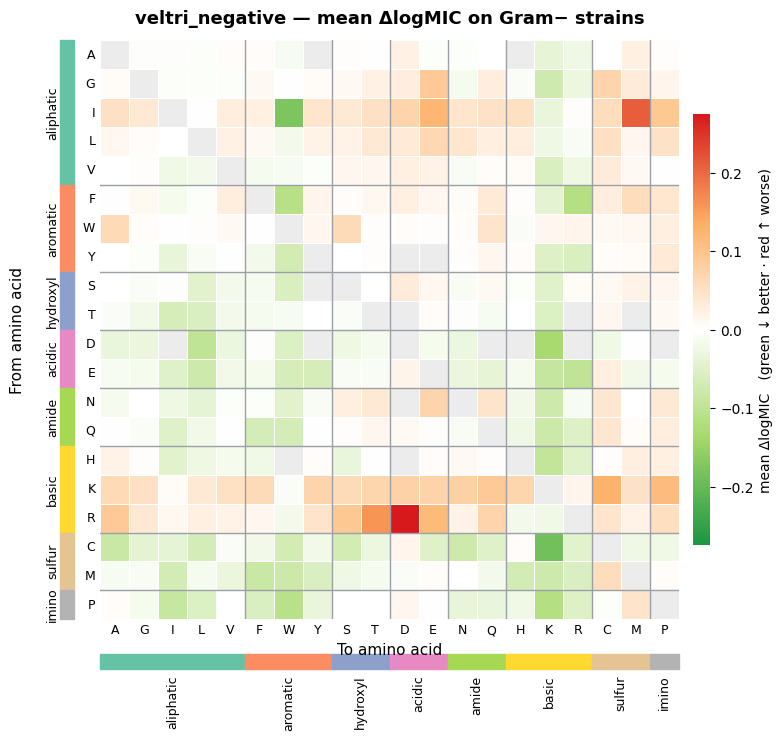

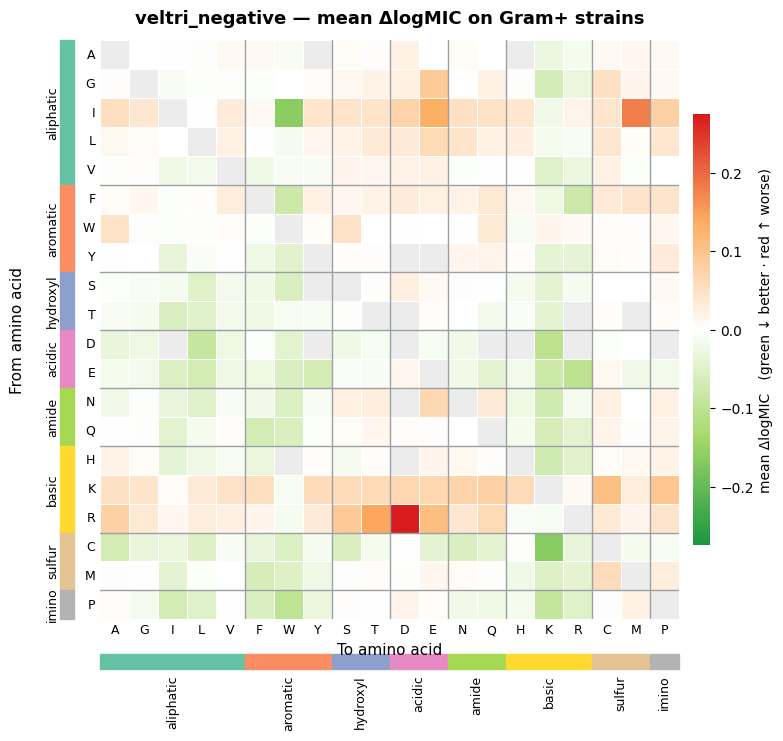

In [6]:
for grp_matrix, grp_name in [(neg_gramneg, "Gram−"), (neg_grampos, "Gram+")]:
    plot_signature_matrix(
        grp_matrix, classification="chemical_type",
        title=f"veltri_negative — mean ΔlogMIC on {grp_name} strains",
        vmin=-VLIM, vmax=VLIM,
    )

## 6. `veltri_positive` mutational signature

The same maps for the **antimicrobial** peptides. Because these are already active, there is
more room for mutations to *worsen* them (push MIC up → red).

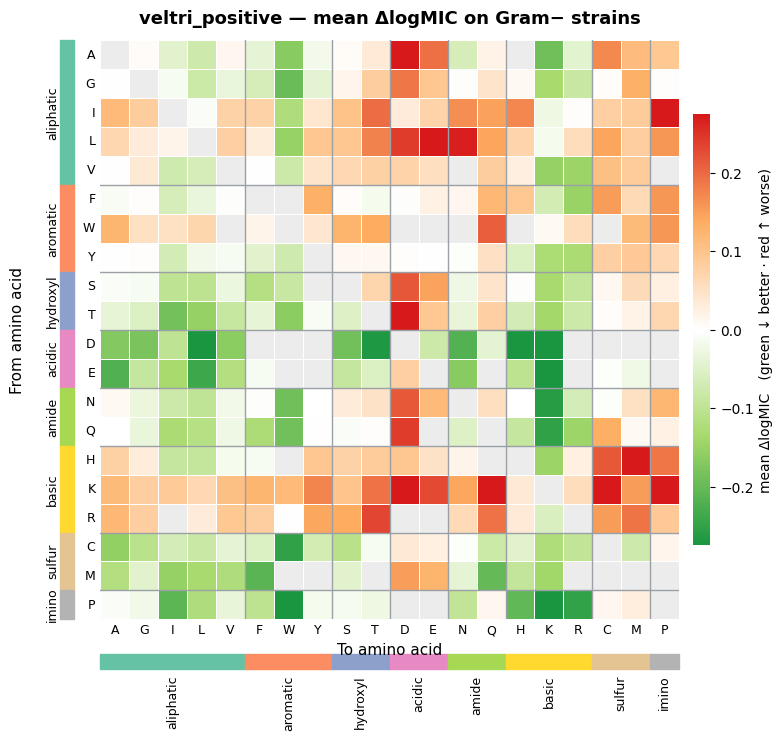

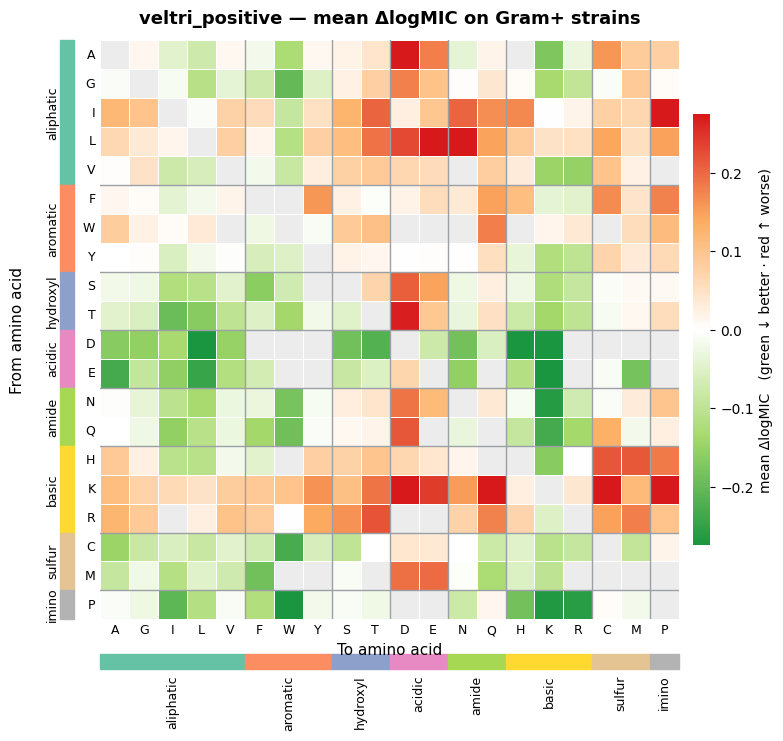

In [7]:
for grp_matrix, grp_name in [(pos_gramneg, "Gram−"), (pos_grampos, "Gram+")]:
    plot_signature_matrix(
        grp_matrix, classification="chemical_type",
        title=f"veltri_positive — mean ΔlogMIC on {grp_name} strains",
        vmin=-VLIM, vmax=VLIM,
    )

## 7. Positive vs negative — side by side and difference

The left two panels repeat the Gram-negative signatures for each split; the right panel is
their **difference** (`positive − negative`). Red in the difference panel marks AA→AA
changes that are *more harmful to MIC* in the active peptides than in the inactive ones.

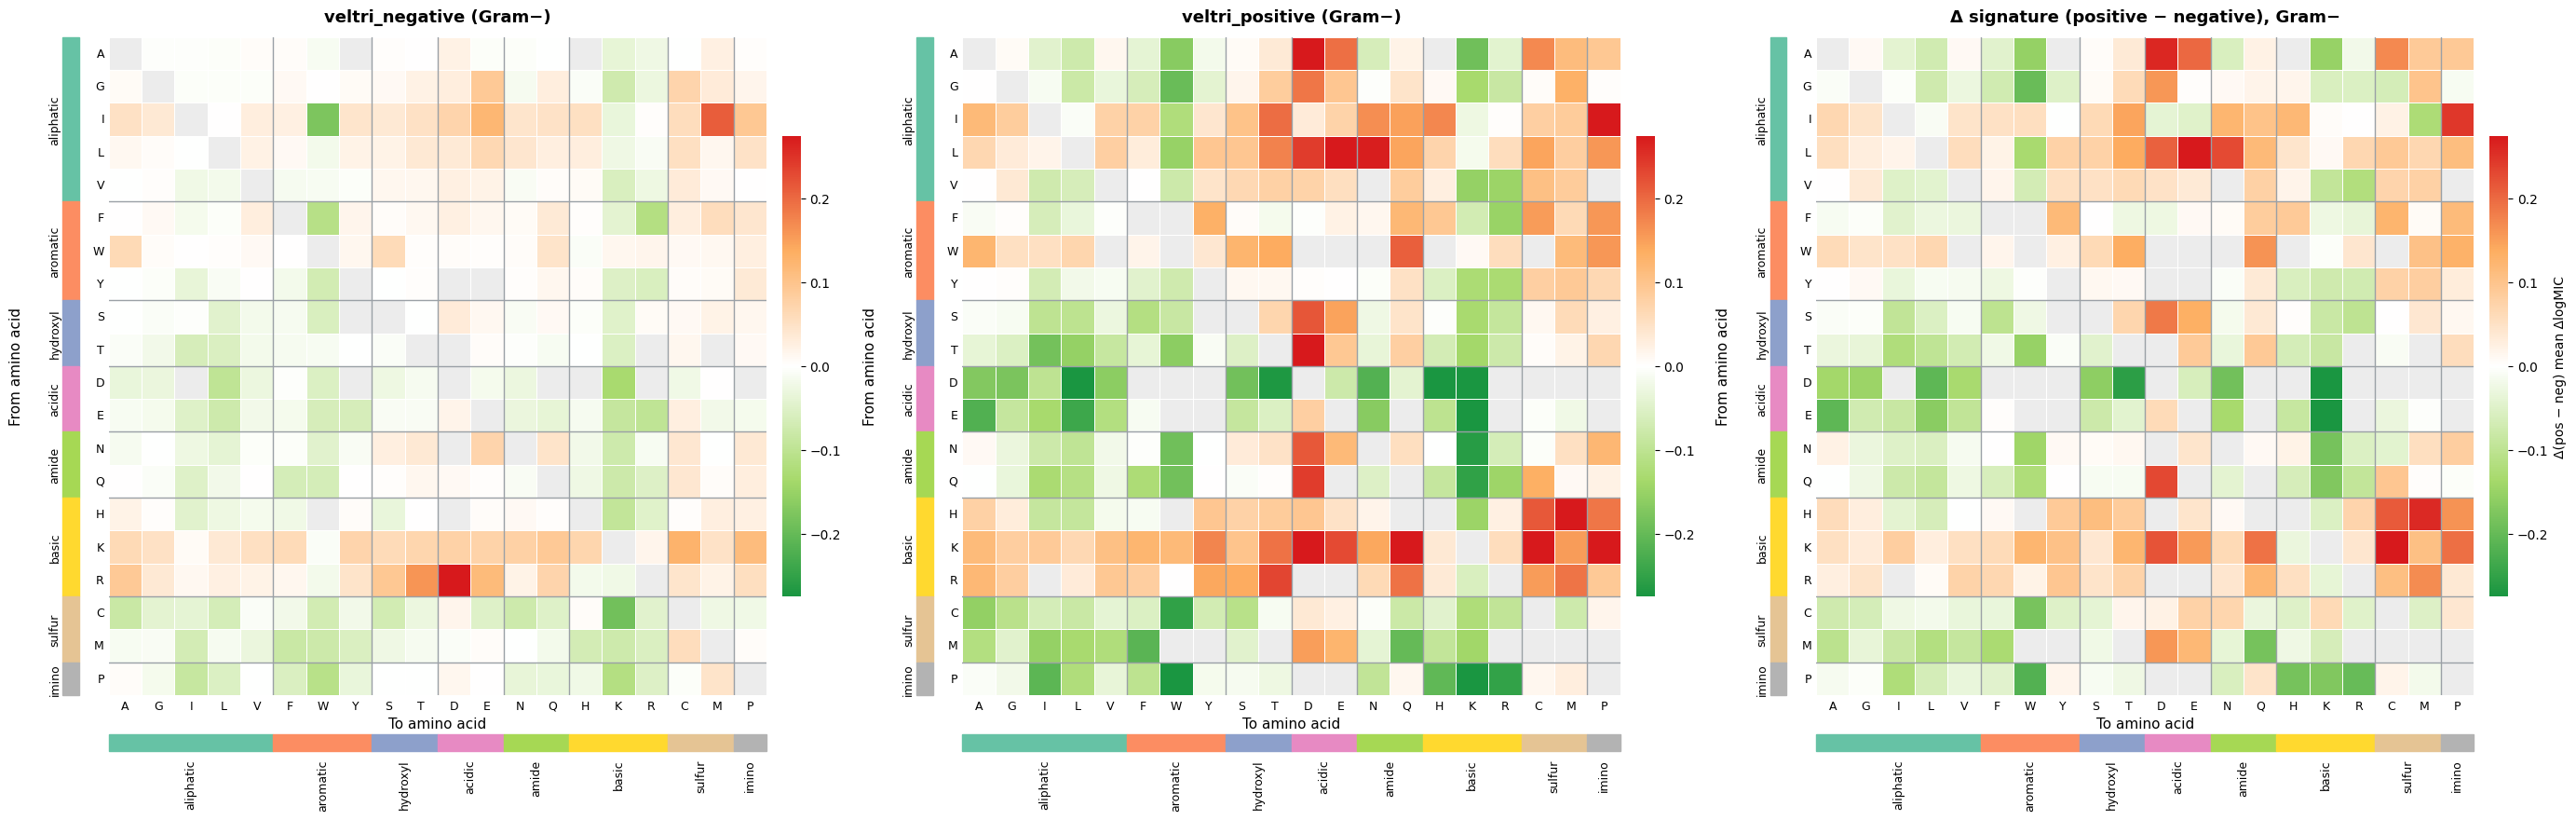

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(28, 8))
plot_signature_matrix(neg_gramneg, title="veltri_negative (Gram−)", vmin=-VLIM, vmax=VLIM,
                      ax=axes[0], cbar_label=None)
plot_signature_matrix(pos_gramneg, title="veltri_positive (Gram−)", vmin=-VLIM, vmax=VLIM,
                      ax=axes[1], cbar_label=None)
diff_matrix = pos_gramneg - neg_gramneg
plot_signature_matrix(diff_matrix, title="Δ signature (positive − negative), Gram−",
                      vmin=-VLIM, vmax=VLIM, ax=axes[2],
                      cbar_label="Δ(pos − neg) mean ΔlogMIC")
plt.tight_layout()
plt.show()

## 8. Quantitative summary

A few aggregate numbers that the conclusions below are based on: the overall mean ΔlogMIC
per split/Gram group (sign tells the dominant direction), and the most strongly
activity-improving (greenest) and activity-harming (reddest) substitutions.

In [9]:
def overall_mean(diff, cols):
    return float(np.nanmean(diff[cols].to_numpy()))

print("Overall mean ΔlogMIC (negative = mutations improve activity on average):")
for name, d in [("veltri_negative", diff_neg), ("veltri_positive", diff_pos)]:
    print(f"  {name:16s}  Gram-: {overall_mean(d, neg_delta_cols):+.4f}   "
          f"Gram+: {overall_mean(d, pos_delta_cols):+.4f}")

def extremes(mat, cnt, min_count=20, k=8):
    flat = [(p, m, mat.at[p, m], cnt.at[p, m]) for p in ALL_AA for m in ALL_AA
            if p != m and np.isfinite(mat.at[p, m]) and cnt.at[p, m] >= min_count]
    flat.sort(key=lambda r: r[2])
    show = lambda rows: [f"{p}->{m} {v:+.3f} (n={n})" for p, m, v, n in rows]
    print("\n  most ACTIVITY-IMPROVING (greenest, ΔlogMIC<0):")
    for s in show(flat[:k]): print("    ", s)
    print("  most ACTIVITY-HARMING  (reddest, ΔlogMIC>0):")
    for s in show(flat[-k:][::-1]): print("    ", s)

print("\n=== veltri_positive, Gram− ===")
extremes(pos_gramneg, pos_cnt)
print("\n=== veltri_negative, Gram− ===")
extremes(neg_gramneg, neg_cnt)

Overall mean ΔlogMIC (negative = mutations improve activity on average):
  veltri_negative   Gram-: -0.0150   Gram+: -0.0135
  veltri_positive   Gram-: +0.0123   Gram+: +0.0129

=== veltri_positive, Gram− ===

  most ACTIVITY-IMPROVING (greenest, ΔlogMIC<0):
     E->K -0.385 (n=26)
     P->K -0.288 (n=491)
     N->K -0.260 (n=342)
     Q->K -0.252 (n=138)
     E->L -0.239 (n=171)
     P->I -0.210 (n=389)
     Q->W -0.189 (n=126)
     D->S -0.188 (n=108)
  most ACTIVITY-HARMING  (reddest, ΔlogMIC>0):
     L->E +0.371 (n=93)
     I->P +0.338 (n=253)
     K->P +0.306 (n=133)
     K->Q +0.283 (n=341)
     A->D +0.283 (n=128)
     L->N +0.270 (n=508)
     K->E +0.228 (n=28)
     S->D +0.219 (n=127)

=== veltri_negative, Gram− ===

  most ACTIVITY-IMPROVING (greenest, ΔlogMIC<0):
     D->K -0.133 (n=24)
     P->K -0.116 (n=528)
     D->L -0.097 (n=61)
     E->K -0.089 (n=63)
     P->I -0.086 (n=408)
     Q->K -0.079 (n=392)
     N->K -0.077 (n=521)
     E->L -0.075 (n=1044)
  most ACTIVITY-H

## 9. Conclusions

**Setup.** We scored every single-position mutant of the two Veltri splits by its log2
fold-change in predicted MIC (`ΔlogMIC = log2 MIC_mutant − log2 MIC_parent`), using the
APEX predictions in `results/data/all_in/`. Green = the mutation **lowers MIC → improves
activity**; red = it **raises MIC → hurts activity**. Sample sizes: `veltri_negative` =
854 parents / 77,297 mutants (22,652 usable single-AA changes); `veltri_positive` = 892
parents / 58,318 mutants (17,943 usable changes).

**1. The two splits move in opposite directions on average.**
- `veltri_negative` (non-antimicrobial peptides): mean ΔlogMIC ≈ **−0.015** (Gram−) /
  **−0.013** (Gram+). Random single substitutions tend to *improve* these inactive
  peptides slightly — there is plenty of headroom to become more active.
- `veltri_positive` (antimicrobial peptides): mean ΔlogMIC ≈ **+0.012** (Gram−) /
  **+0.013** (Gram+). Already-active peptides are mostly *degraded* by a random single
  change — they sit nearer an activity optimum.

**2. The signature is dominated by charge, and the lever is Lysine (K).**
In *both* splits the strongest activity-improving substitutions are the ones that
**introduce a positive charge** (→K): `E→K`, `P→K`, `N→K`, `Q→K`, `D→K` are the greenest
cells. Symmetrically, the most harmful moves **remove positive charge or add negative
charge**: `K→P`, `K→Q`, `K→E`, `K→N`, and `→D / →E` substitutions (`L→E`, `A→D`, `S→D`)
are the reddest. This is the canonical cationic-AMP mechanism — net positive charge drives
membrane binding — recovered purely from the predicted-MIC signature.

**3. Proline is a consistent activity-breaker.**
`→P` substitutions (`I→P`, `K→P`) are among the reddest in both splits, consistent with
proline disrupting the amphipathic helix that AMPs use to insert into membranes; the
reverse `P→K` / `P→I` are strongly green.

**4. Gram− and Gram+ signatures are nearly identical.**
The Gram-negative and Gram-positive matrices agree closely in both sign and structure, and
the overall means differ by <0.002 within each split. The model has learned a
**charge/hydrophobicity rule that generalises across the Gram divide** rather than
strain-specific chemistry.

**5. Active peptides are ~2–3× more sensitive than inactive ones.**
The strongest effects in `veltri_positive` (e.g. `E→K` −0.385, `L→E` +0.371) are roughly
2–3× larger than the corresponding extremes in `veltri_negative` (`D→K` −0.133, `K→P`
+0.113). The positive/negative difference map (§7) is therefore mostly red on
charge-destroying moves: the same substitution costs an *active* peptide much more activity
than it costs an already-inactive one.

**Takeaway.** A single APEX-derived mutational-signature picture reproduces known AMP design
rules — *add cationic residues (especially Lys), avoid acidic residues and proline* — and
shows that this rule is symmetric (it improves non-AMPs and, when reversed, is exactly what
most damages AMPs), Gram-agnostic, and strongest in peptides that are already active.